In [13]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [3]:
df= pd.read_csv('weight-height.csv')

In [4]:
weight_mean = df["Weight"].mean()
weight_std = df["Weight"].std()
height_mean = df["Height"].mean()
height_std = df["Height"].std()

In [5]:
df['Weight_zscore']=zscore(df['Weight'])
df['Height_zscore']=zscore(df['Height'])

In [6]:
print(f"Mean of Weight:{weight_mean:.2f}")
print(f"Standard Deviation:{weight_std:.2f}")
print(f"Mean of Height:{height_mean:.2f}")
print(f"Standard Deviation:{height_std:.2f}")

Mean of Weight:161.44
Standard Deviation:32.11
Mean of Height:66.37
Standard Deviation:3.85


In [25]:
#Save the modified DF to a CSV file
df.to_csv('heights-weights-with-z-scores.csv')

In [9]:
#Outlier Analysis
zscore_threshold = 3

In [11]:
weight_outliers = df[(df['Weight_zscore'].abs()>zscore_threshold)]
height_outliers = df[(df['Height_zscore'].abs()>zscore_threshold)]
all_outliers =pd.concat([weight_outliers, height_outliers]).drop_duplicates()

In [12]:
print(f"\nNumber of Weight outliers(z-score > {zscore_threshold}):{len(weight_outliers)}")
print(f"\nNumber of Height outliers(z-score > {zscore_threshold}):{len(height_outliers)}")
print(f"Total unique outliers found:{len(all_outliers)}")


Number of Weight outliers(z-score > 3):2

Number of Height outliers(z-score > 3):7
Total unique outliers found:7


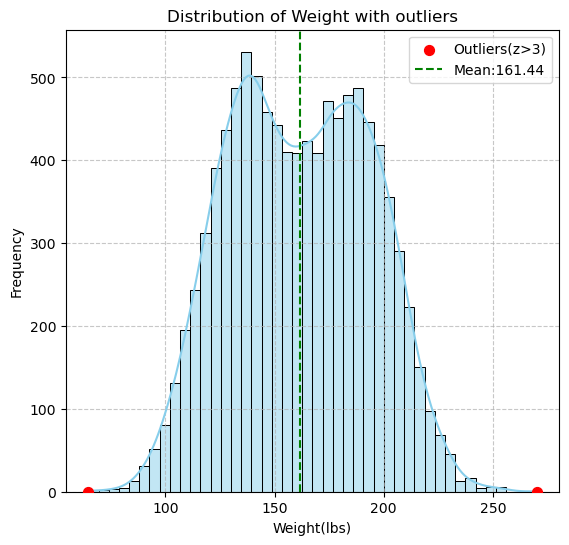

In [17]:
plt.figure(figsize=(14,6))
#Plot for weight
plt.subplot(1,2,1) #1 row, 2 columns, 1st plot
sns.histplot(df['Weight'], kde=True,color='skyblue')
plt.scatter(weight_outliers['Weight'],[0]*len(weight_outliers),color='red',s=50,zorder=5,label=f'Outliers(z>{zscore_threshold})')
plt.axvline(weight_mean,color='green',linestyle='--',label=f'Mean:{weight_mean:.2f}')
plt.title('Distribution of Weight with outliers')
plt.xlabel('Weight(lbs)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True,linestyle='--',alpha=0.7)

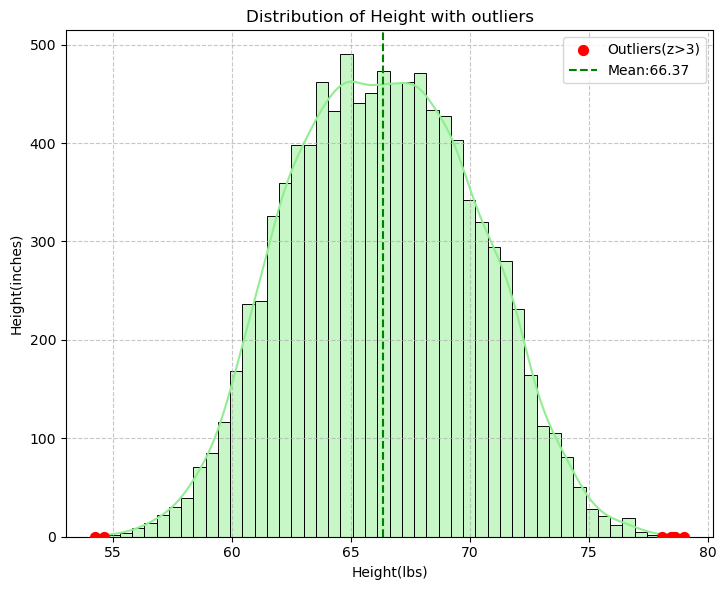

In [21]:
#Plot for Height
plt.figure(figsize=(14,6))
plt.subplot(1,2,2)
sns.histplot(df['Height'],kde=True,color='lightgreen')
plt.scatter(height_outliers['Height'],[0]*len(height_outliers),color='red',s=50,zorder=5,label=f'Outliers(z>{zscore_threshold})')
plt.axvline(height_mean,color='green',linestyle='--',label=f'Mean:{height_mean:.2f}')
plt.title('Distribution of Height with outliers')
plt.xlabel('Height(lbs)')
plt.ylabel('Height(inches)')
plt.legend()
plt.grid(True,linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()

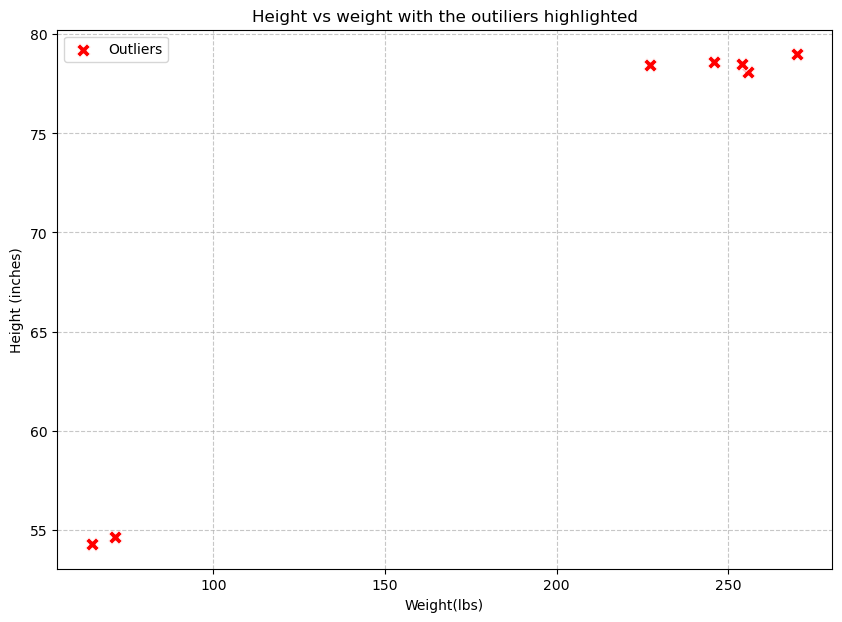

In [24]:
#Scatter Plot of Height vs Weight with outliers highlighted 
plt.figure(figsize=(10,7))
sns.scatterplot(x='Weight', y='Height', data=all_outliers,color='red', s=100, label='Outliers', marker='X')
plt.title('Height vs Weight with the outiliers highlighted')
plt.xlabel('Weight(lbs)')
plt.ylabel('Height (inches)')
plt.legend()
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()

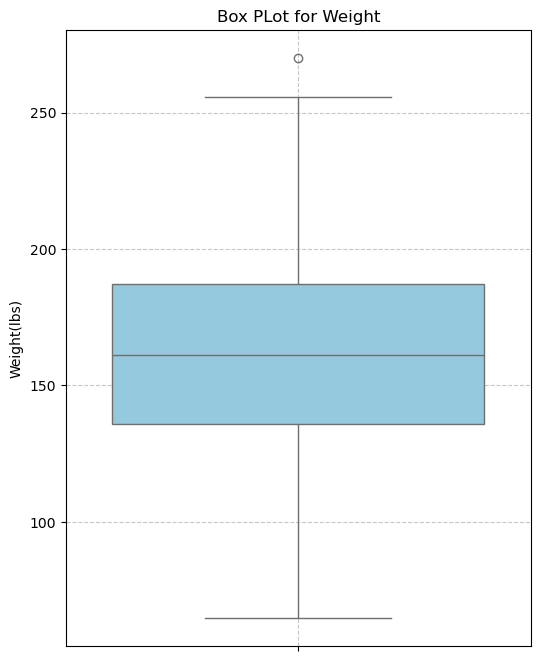

In [26]:
#Box Plot for Weight
plt.figure(figsize=(6,8))
sns.boxplot(y=df['Weight'],color='skyblue')
plt.title('Box PLot for Weight')
plt.ylabel('Weight(lbs)')
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()

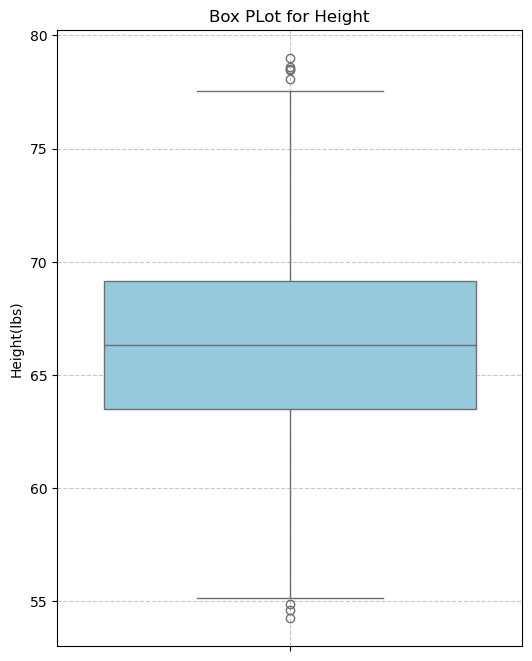

In [27]:
#Box Plot for Height
plt.figure(figsize=(6,8))
sns.boxplot(y=df['Height'],color='skyblue')
plt.title('Box PLot for Height')
plt.ylabel('Height(lbs)')
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()